# Solutions · 02 · Root finding: solving $f(x) = 0$

Worked solutions to the exercises of [notebook 02](../notebooks/02_root_finding.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import roots
eps, D, Re = 0.045e-3, 0.05, 2e5
def colebrook(f):
    return 1/np.sqrt(f) + 2*np.log10(eps/D/3.7 + 2.51/(Re*np.sqrt(f)))

## Exercise 1

Solve the van der Waals equation $(P + a/V_m^2)(V_m - b) = RT$ for the molar volume of CO₂ at
   50 bar and 300 K ($a$ = 0.364 Pa·m⁶/mol², $b$ = 4.27×10⁻⁵ m³/mol). How many real roots are there
   at 280 K and 50 bar? Plot the cubic to find out.

T = 300 K, 50 bar: 1 real root(s), V_m = [365.7] cm³/mol (ideal gas 499 cm³/mol)
T = 280 K, 50 bar: 3 real root(s), V_m = [ 82.6 125.4 300.4] cm³/mol (ideal gas 466 cm³/mol)


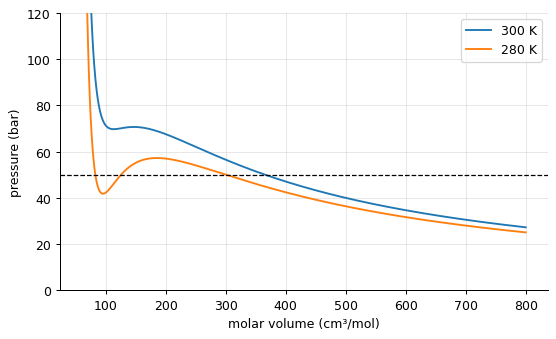

In [2]:
a, b, R = 0.364, 4.27e-5, 8.314
def vdw_roots(P, T):
    # (P + a/V^2)(V - b) = RT  <=>  P V^3 - (P b + R T) V^2 + a V - a b = 0
    r = np.roots([P, -(P*b + R*T), a, -a*b])
    return np.sort(r[np.abs(r.imag) < 1e-12].real)
for T in (300.0, 280.0):
    Vs = vdw_roots(50e5, T)
    print(f"T = {T:.0f} K, 50 bar: {len(Vs)} real root(s), V_m = {np.round(Vs*1e6, 1)} cm³/mol "
          f"(ideal gas {R*T/50e5*1e6:.0f} cm³/mol)")
V = np.linspace(6e-5, 8e-4, 500)
for T in (300.0, 280.0):
    plt.plot(V*1e6, (R*T/(V - b) - a/V**2)/1e5, label=f"{T:.0f} K")
plt.axhline(50, color="k", ls="--", lw=1); plt.ylim(0, 120)
plt.xlabel("molar volume (cm³/mol)"); plt.ylabel("pressure (bar)"); plt.legend(); plt.show()

At 300 K the isotherm crosses 50 bar once: one real root, a gas-like molar volume about a quarter below
the ideal-gas value. At 280 K - below the van der Waals critical temperature (about 304 K) - the isotherm has
a loop, and 50 bar cuts it three times: the smallest root is liquid-like, the largest gas-like, and the
middle one is physically unstable. Plotting first shows how many roots to look for, and where to
bracket each one.

## Exercise 2

Implement the fixed-point iteration $f_{k+1} = [-2\log_{10}(\ldots f_k\ldots)]^{-2}$ for Colebrook.
   Estimate its convergence order and compare with Newton.

In [3]:
def g(f):                       # fixed-point form: f = g(f)
    return (-2*np.log10(eps/D/3.7 + 2.51/(Re*np.sqrt(f))))**-2
f_star = roots.brent(colebrook, 0.005, 0.08, tol=1e-15).root
f, errs = 0.02, []
for k in range(30):
    f = g(f); errs.append(abs(f - f_star))
    if errs[-1] < 1e-15:
        break
ratios = np.array(errs[1:6]) / np.array(errs[:5])
print(f"fixed point: {len(errs)} iterations; error ratios {np.round(ratios, 4)}")
print(f"Newton from the same start: {roots.newton(colebrook, 0.02, tol=1e-15).iterations} iterations")

fixed point: 8 iterations; error ratios [0.0329 0.033  0.033  0.033  0.033 ]
Newton from the same start: 5 iterations


The error shrinks by a roughly **constant factor** each iteration: linear convergence (order 1). Here the
factor is very small, because $g$ depends only weakly on $f$ - so fixed-point iteration is a perfectly
good method for Colebrook, and simple to program. Newton converges quadratically but needs derivatives;
for this particular equation the difference in iteration count is modest.

## Exercise 3

Add Haaland's explicit approximation to the Moody diagram and plot its relative error.

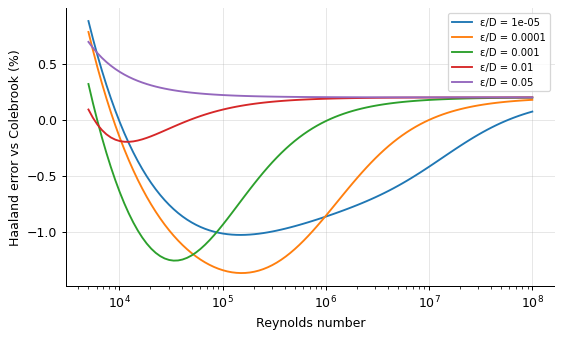

largest deviation: 1.37 %


In [4]:
def haaland(Re, rel):
    return (-1.8*np.log10((rel/3.7)**1.11 + 6.9/Re))**-2
Re_range = np.logspace(3.7, 8, 100)
fig, ax = plt.subplots()
worst = 0
for rel in [1e-5, 1e-4, 1e-3, 1e-2, 5e-2]:
    fc = np.array([roots.brent(lambda f: 1/np.sqrt(f) + 2*np.log10(rel/3.7 + 2.51/(R_*np.sqrt(f))), 1e-4, 1).root
                   for R_ in Re_range])
    err = 100 * (haaland(Re_range, rel) / fc - 1)
    worst = max(worst, np.max(np.abs(err)))
    ax.semilogx(Re_range, err, label=f"ε/D = {rel:g}")
ax.set(xlabel="Reynolds number", ylabel="Haaland error vs Colebrook (%)"); ax.legend(fontsize=8); plt.show()
print(f"largest deviation: {worst:.2f} %")

Haaland's explicit formula stays within about 1.5 % of Colebrook over the whole turbulent range - smaller
than the uncertainty of Colebrook itself (roughly 5-15 % against measurements). For hand calculations
the explicit formula is fine; in software, solving Colebrook costs almost nothing.

## Exercise 4

**Implement it yourself:** write the *regula falsi* (false position) method: bisection, but split the bracket where the straight line through $(a, g(a))$ and $(b, g(b))$ crosses zero. Compare its iteration count with bisection on the Colebrook equation. Why can it be slow when one end of the bracket never moves?

In [5]:
def regula_falsi(g, a, b, tol=1e-12, maxiter=500):
    ga, gb = g(a), g(b)
    moved = {"a": 0, "b": 0}
    for k in range(1, maxiter + 1):
        c = b - gb * (b - a) / (gb - ga)       # where the chord crosses zero
        gc = g(c)
        if abs(gc) < tol or min(abs(c - a), abs(b - c)) < tol:
            return c, k, moved
        if ga * gc < 0:
            b, gb = c, gc; moved["b"] += 1
        else:
            a, ga = c, gc; moved["a"] += 1
    return c, maxiter, moved

root, its, moved = regula_falsi(colebrook, 0.005, 0.08)
print(f"regula falsi: f = {root:.12f} after {its} iterations; endpoint updates {moved}")
print(f"bisection:    {roots.bisection(colebrook, 0.005, 0.08).iterations} iterations")

regula falsi: f = 0.020635277206 after 53 iterations; endpoint updates {'a': 0, 'b': 52}
bisection:    37 iterations


Look at which endpoint moved: only one. $g$ is convex on this bracket, so every chord crosses zero on the
same side of the root and the other endpoint is never replaced. The bracket then shrinks from one side
only and convergence becomes linear - here slower than halving the bracket. Modified versions (the
Illinois method, which halves the stuck endpoint's function value) and Brent's method fix exactly this.